In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\hp\Desktop\HR_Analytics\HR-Employee-Attrition _cleaned.csv")

In [4]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [7]:
# Number of unique values in each column
df.nunique().sort_values()

Over18                         1
StandardHours                  1
EmployeeCount                  1
Gender                         2
Attrition                      2
PerformanceRating              2
OverTime                       2
MaritalStatus                  3
Department                     3
BusinessTravel                 3
StockOptionLevel               4
EnvironmentSatisfaction        4
JobInvolvement                 4
JobSatisfaction                4
RelationshipSatisfaction       4
WorkLifeBalance                4
Education                      5
JobLevel                       5
EducationField                 6
TrainingTimesLastYear          7
JobRole                        9
NumCompaniesWorked            10
PercentSalaryHike             15
YearsSinceLastPromotion       16
YearsWithCurrManager          18
YearsInCurrentRole            19
DistanceFromHome              29
YearsAtCompany                37
TotalWorkingYears             40
Age                           43
HourlyRate

In [8]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


Attrition
Attrition
No     1233
Yes     237
Name: count, dtype: int64

BusinessTravel
BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

Department
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

EducationField
EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

Gender
Gender
Male      882
Female    588
Name: count, dtype: int64

JobRole
JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

MaritalStatus
MaritalStatus
Married     673


In [9]:
df = df.drop(columns=[
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
])

In [10]:
attrition_count = df["Attrition"].value_counts()

print(attrition_count)

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [11]:
attrition_rate = (
    df["Attrition"].eq("Yes").mean() * 100
)

print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


In [ ]:
df = df.drop(columns=[
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
])

print("New Shape:", df.shape)

In [13]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [15]:
df.shape

(1470, 31)

In [17]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

In [19]:
total_employees = df.shape[0]

print("Total Employees:", total_employees)

Total Employees: 1470


In [20]:
attrition_count = df["Attrition"].value_counts()

print(attrition_count)

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [21]:
attrition_rate = df["Attrition"].eq("Yes").mean() * 100

print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


In [22]:
print("Average Age:", round(df["Age"].mean(), 2))
print("Average Monthly Income:", round(df["MonthlyIncome"].mean(), 2))
print("Average Total Working Years:", round(df["TotalWorkingYears"].mean(), 2))
print("Average Years at Company:", round(df["YearsAtCompany"].mean(), 2))

Average Age: 36.92
Average Monthly Income: 6502.93
Average Total Working Years: 11.28
Average Years at Company: 7.01


In [23]:
df.groupby("Department")["Attrition"].value_counts()

Department              Attrition
Human Resources         No            51
                        Yes           12
Research & Development  No           828
                        Yes          133
Sales                   No           354
                        Yes           92
Name: count, dtype: int64

In [28]:
dept_rate = (
    df.groupby("Department")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

print(dept_rate.round(2))

Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: float64


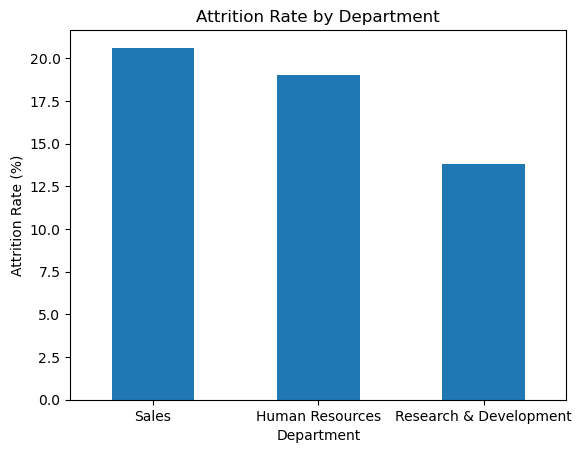

In [29]:
import matplotlib.pyplot as plt

dept_rate.plot(kind="bar")

plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [30]:
role_rate = (
    df.groupby("JobRole")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

print(role_rate.round(2))

JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition, dtype: float64


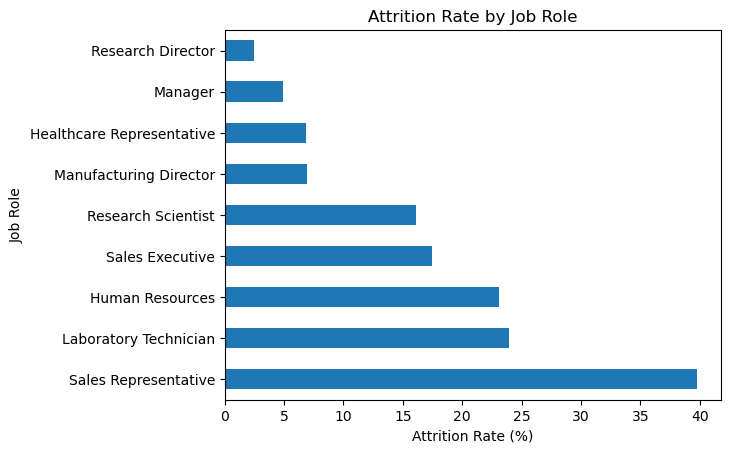

In [31]:
role_rate.plot(kind="barh")
plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")
plt.show()

In [32]:
overtime_rate = (
    df.groupby("OverTime")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

print(overtime_rate.round(2))

OverTime
No     10.44
Yes    30.53
Name: Attrition, dtype: float64


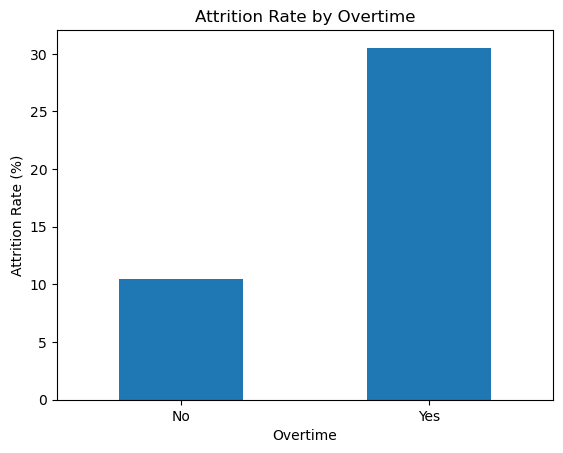

In [33]:
overtime_rate.plot(kind="bar")

plt.title("Attrition Rate by Overtime")
plt.xlabel("Overtime")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [34]:
travel_rate = (
    df.groupby("BusinessTravel")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

print(travel_rate.round(2))

BusinessTravel
Travel_Frequently    24.91
Travel_Rarely        14.96
Non-Travel            8.00
Name: Attrition, dtype: float64


In [35]:
marital_rate = (
    df.groupby("MaritalStatus")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

print(marital_rate.round(2))

MaritalStatus
Single      25.53
Married     12.48
Divorced    10.09
Name: Attrition, dtype: float64


In [36]:
gender_rate = (
    df.groupby("Gender")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

print(gender_rate.round(2))

Gender
Male      17.01
Female    14.80
Name: Attrition, dtype: float64


In [37]:
df["Age"].describe()

count    1470.000000
mean       36.923810
std         9.135373
min        18.000000
25%        30.000000
50%        36.000000
75%        43.000000
max        60.000000
Name: Age, dtype: float64

In [38]:
age_attrition = (
    df.groupby("Age")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

print(age_attrition.round(2))

Age
18    50.00
19    66.67
20    54.55
21    46.15
22    31.25
23    28.57
24    26.92
25    23.08
26    30.77
27     6.25
28    29.17
29    26.47
30    15.00
31    26.09
32    18.03
33    20.69
34    11.69
35    12.82
36     8.70
37    12.00
38     3.45
39    14.29
40     8.77
41    15.00
42     4.35
43     6.25
44    18.18
45     4.88
46    12.12
47    12.50
48    10.53
49     8.33
50    16.67
51    10.53
52    16.67
53    10.53
54     0.00
55    13.64
56    21.43
57     0.00
58    35.71
59     0.00
60     0.00
Name: Attrition, dtype: float64


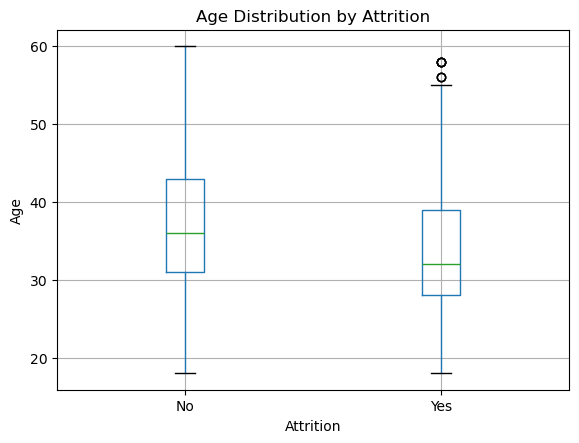

In [39]:


df.boxplot(column="Age", by="Attrition")

plt.title("Age Distribution by Attrition")
plt.suptitle("")
plt.xlabel("Attrition")
plt.ylabel("Age")
plt.show()

In [40]:
df["DistanceFromHome"].describe()

count    1470.000000
mean        9.192517
std         8.106864
min         1.000000
25%         2.000000
50%         7.000000
75%        14.000000
max        29.000000
Name: DistanceFromHome, dtype: float64

In [41]:
distance_attrition = (
    df.groupby("DistanceFromHome")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

print(distance_attrition.round(2))

DistanceFromHome
24    42.86
13    31.58
22    31.58
12    30.00
27    25.00
17    25.00
25    24.00
16    21.88
9     21.18
15    19.23
14    19.05
23    18.52
29    18.52
21    16.67
3     16.67
20    16.00
18    15.38
5     15.38
4     14.06
11    13.79
19    13.64
2     13.27
7     13.10
10    12.79
8     12.50
1     12.50
26    12.00
6     11.86
28     8.70
Name: Attrition, dtype: float64


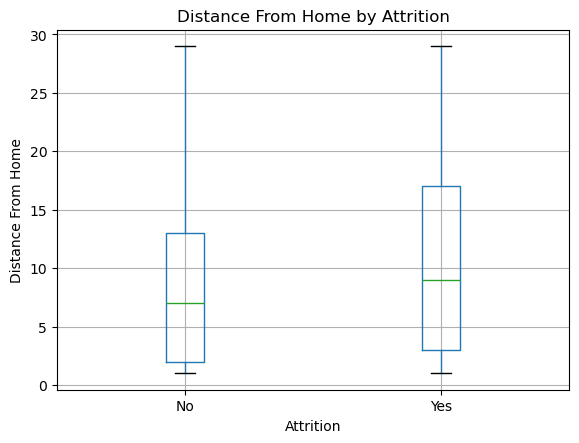

In [42]:
df.boxplot(column="DistanceFromHome", by="Attrition")

plt.title("Distance From Home by Attrition")
plt.suptitle("")
plt.xlabel("Attrition")
plt.ylabel("Distance From Home")
plt.show()

In [43]:
education_rate = (
    df.groupby("Education")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

print(education_rate.round(2))

Education
1    18.24
3    17.31
2    15.60
4    14.57
5    10.42
Name: Attrition, dtype: float64


In [44]:
education_field_rate = (
    df.groupby("EducationField")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

print(education_field_rate.round(2))

EducationField
Human Resources     25.93
Technical Degree    24.24
Marketing           22.01
Life Sciences       14.69
Medical             13.58
Other               13.41
Name: Attrition, dtype: float64


In [45]:
print(df["Education"].value_counts().sort_index())
print()
print(df["EducationField"].value_counts())

Education
1    170
2    282
3    572
4    398
5     48
Name: count, dtype: int64

EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64


In [47]:
df.groupby("Attrition")["MonthlyIncome"].describe()

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
No,1233.0,6832.739659,4818.208001,1051.0,3211.0,5204.0,8834.0,19999.0
Yes,237.0,4787.092827,3640.210367,1009.0,2373.0,3202.0,5916.0,19859.0


In [51]:
print(
    df.groupby("Attrition")["MonthlyIncome"]
      .agg(["mean", "median", "min", "max"])
      .round(2)
)

              mean  median   min    max
Attrition                              
No         6832.74  5204.0  1051  19999
Yes        4787.09  3202.0  1009  19859


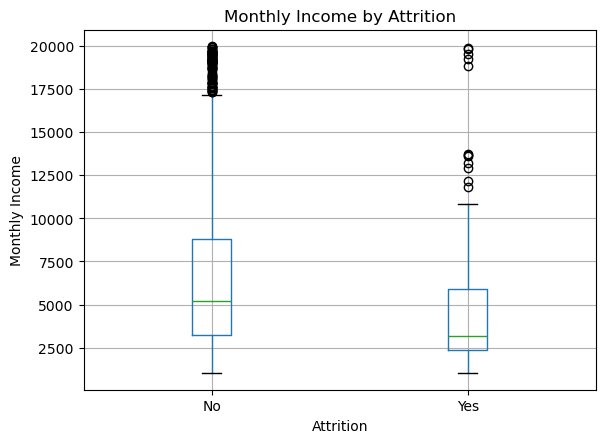

In [52]:
df.boxplot(column="MonthlyIncome", by="Attrition")

plt.title("Monthly Income by Attrition")
plt.suptitle("")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")
plt.show()

In [53]:
joblevel_rate = (
    df.groupby("JobLevel")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
      .sort_values(ascending=False)
)

print(joblevel_rate.round(2))

JobLevel
1    26.34
3    14.68
2     9.74
5     7.25
4     4.72
Name: Attrition, dtype: float64


In [54]:
salary_hike_rate = (
    df.groupby("PercentSalaryHike")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

print(salary_hike_rate.round(2))

PercentSalaryHike
11    19.52
12    16.67
13    16.27
14    11.94
15    17.82
16    17.95
17    17.07
18    14.61
19    11.84
20    12.73
21    10.42
22    21.43
23    21.43
24    28.57
25     5.56
Name: Attrition, dtype: float64


In [5]:
job_sat_rate = (
    df.groupby("JobSatisfaction")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

print(job_sat_rate.round(2))

JobSatisfaction
1    22.84
2    16.43
3    16.52
4    11.33
Name: Attrition, dtype: float64


In [6]:
env_sat_rate = (
    df.groupby("EnvironmentSatisfaction")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

print(env_sat_rate.round(2))

EnvironmentSatisfaction
1    25.35
2    14.98
3    13.69
4    13.45
Name: Attrition, dtype: float64


In [7]:
worklife_rate = (
    df.groupby("WorkLifeBalance")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

print(worklife_rate.round(2))

WorkLifeBalance
1    31.25
2    16.86
3    14.22
4    17.65
Name: Attrition, dtype: float64


In [8]:
involvement_rate = (
    df.groupby("JobInvolvement")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

print(involvement_rate.round(2))

JobInvolvement
1    33.73
2    18.93
3    14.40
4     9.03
Name: Attrition, dtype: float64


In [9]:
relationship_rate = (
    df.groupby("RelationshipSatisfaction")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

print(relationship_rate.round(2))

RelationshipSatisfaction
1    20.65
2    14.85
3    15.47
4    14.81
Name: Attrition, dtype: float64


In [10]:
total_work_rate = (
    df.groupby("TotalWorkingYears")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

print(total_work_rate.round(2))

TotalWorkingYears
0      45.45
1      49.38
2      29.03
3      21.43
4      19.05
5      18.18
6      17.60
7      22.22
8      15.53
9      10.42
10     12.38
11     19.44
12     10.42
13      8.33
14     12.90
15     12.50
16      8.11
17      9.09
18     14.81
19     13.64
20      6.67
21      2.94
22      9.52
23      9.09
24     16.67
25      7.14
26      7.14
27      0.00
28      7.14
29      0.00
30      0.00
31     11.11
32      0.00
33     14.29
34     20.00
35      0.00
36      0.00
37      0.00
38      0.00
40    100.00
Name: Attrition, dtype: float64


In [11]:
company_year_rate = (
    df.groupby("YearsAtCompany")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

print(company_year_rate.round(2))

YearsAtCompany
0      36.36
1      34.50
2      21.26
3      15.62
4      17.27
5      10.71
6      11.84
7      12.22
8      11.25
9       9.76
10     15.00
11      6.25
12      0.00
13      8.33
14     11.11
15      5.00
16      8.33
17     11.11
18      7.69
19      9.09
20      3.70
21      7.14
22      6.67
23     50.00
24     16.67
25      0.00
26      0.00
27      0.00
29      0.00
30      0.00
31     33.33
32     33.33
33     20.00
34      0.00
36      0.00
37      0.00
40    100.00
Name: Attrition, dtype: float64


In [12]:
role_year_rate = (
    df.groupby("YearsInCurrentRole")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

print(role_year_rate.round(2))

YearsInCurrentRole
0     29.92
1     19.30
2     18.28
3     11.85
4     14.42
5      2.78
6      5.41
7     13.96
8      7.87
9      8.96
10     6.90
11     0.00
12    10.00
13     7.14
14     9.09
15    25.00
16     0.00
17     0.00
18     0.00
Name: Attrition, dtype: float64


In [13]:
promotion_rate = (
    df.groupby("YearsSinceLastPromotion")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

print(promotion_rate.round(2))

YearsSinceLastPromotion
0     18.93
1     13.73
2     16.98
3     17.31
4      8.20
5      4.44
6     18.75
7     21.05
8      0.00
9     23.53
10    16.67
11     8.33
12     0.00
13    20.00
14    11.11
15    23.08
Name: Attrition, dtype: float64


In [14]:
manager_rate = (
    df.groupby("YearsWithCurrManager")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

print(manager_rate.round(2))

YearsWithCurrManager
0     32.32
1     14.47
2     14.53
3     13.38
4     11.22
5     12.90
6     13.79
7     14.35
8      9.35
9      9.38
10    11.11
11     4.55
12     0.00
13     0.00
14    40.00
15     0.00
16     0.00
17     0.00
Name: Attrition, dtype: float64


In [15]:
companies_rate = (
    df.groupby("NumCompaniesWorked")["Attrition"]
      .apply(lambda x: (x == "Yes").mean() * 100)
)

print(companies_rate.round(2))

NumCompaniesWorked
0    11.68
1    18.81
2    10.96
3    10.06
4    12.23
5    25.40
6    22.86
7    22.97
8    12.24
9    23.08
Name: Attrition, dtype: float64


In [17]:
df.to_csv(
    r"C:\Users\hp\Desktop\HR_Analytics\HR_Employee_Attrition_Cleaned.csv",
    index=False
)